# Chapter 2 - Binary Classification

*What is the difference between true and false?* In this chapter we build a network that must decide between **two** classes: is a movie review positive or negative?

We use the **IMDB dataset**: 25,000 movie reviews, each labeled 0 (negative) or 1 (positive). Words are encoded as integer IDs, so a review is a sequence of integers that we turn into a "bag of words" style vector: for each document we count how many times each of the vocabulary words appears.

## Big idea: from text to numbers
Text is not numeric, networks only eat numbers. Two classic approaches:
1. **One-hot encoding** - a huge vector where each dimension is *present/absent* for one word (sparse and wasteful).
2. **Bag-of-words + frequency** - count occurrences (still sparse).

We actually won't use either directly: we encode with a fixed-size integer index list and let an **Embedding** layer learn dense numeric vectors (chapter 7 covers this fully). 

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.datasets import imdb
from keras import layers, models

print("Keras", keras.__version__)

Keras 3.15.1


## Step 1 - load IMDB, keep top 10k frequent words
Limiting to `num_words=10000` keeps the vocabulary small (and the memory tiny). `maxlen` not used here yet -- we'll explain why we drop it to a fixed length.

In [2]:
vocab_size = 10000
maxlen = 256

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=vocab_size)
print("train data length:", len(train_data))
print("labels:", train_labels[:10])
print("sample review (word indexes):", train_data[0][:15])

train data length: 25000
labels: [1 0 0 1 0 0 1 0 1 0]
sample review (word indexes): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]


## Step 2 - vectorize / truncate to fixed length
Reviews have variable length; `pad_sequences` pads shorter ones with 0 and truncates longer ones so we end with a uniform `(num_samples, maxlen)` integer tensor.

In [3]:
from keras.utils import pad_sequences

x_train = pad_sequences(train_data, maxlen=maxlen)
x_test = pad_sequences(test_data, maxlen=maxlen)

y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

print("x_train", x_train.shape, "x_test", x_test.shape)

x_train (25000, 256) x_test (25000, 256)


## Step 3 - The model: Embedding -> Flatten -> Dense -> single sigmoid
- `Embedding(vocab_size, 16)` learns a 16-dim numeric vector for each of the 10000 words.
- `Flatten` -> one long vector for the whole review.
- Final `Dense(1, sigmoid)`: the classic **binary** output -- a probability in (0,1).

In [4]:
model = models.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(vocab_size, 16),
    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 256, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        65,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,569 (881.13 KB)

 Trainable params: 225,569 (881.13 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10, batch_size=512, verbose=1,
)

Epoch 1/10


 1/49 ━━━━━━━━━━━━━━━━━━━━ 32s 686ms/step - accuracy: 0.5117 - loss: 0.6931

 4/49 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5029 - loss: 0.6930  

 7/49 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5084 - loss: 0.6930

10/49 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5129 - loss: 0.6928

...

40/49 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9380 - loss: 0.1772

43/49 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9385 - loss: 0.1754

46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9395 - loss: 0.1735

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9390 - loss: 0.1749

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9390 - loss: 0.1749 - val_accuracy: 0.8020 - val_loss: 0.5076


## Step 4 - Plot training curves & final score

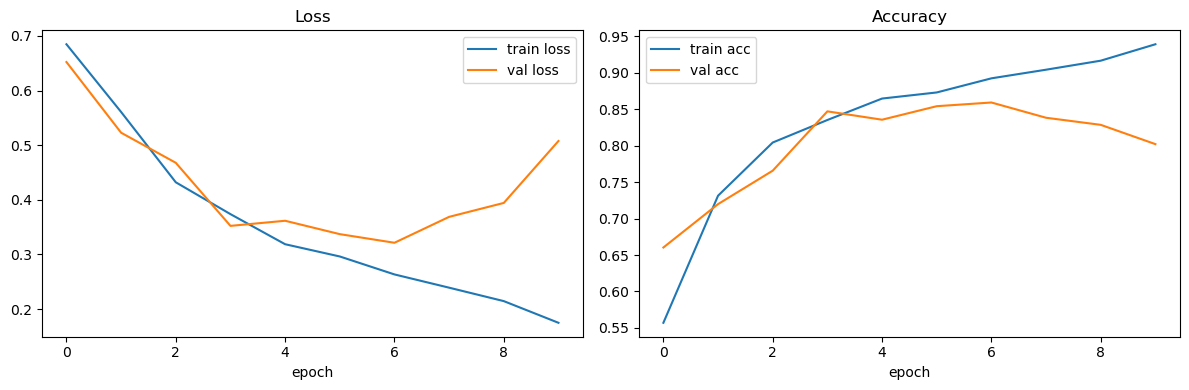

In [6]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history["loss"], label="train loss")
    ax[0].plot(history.history["val_loss"], label="val loss")
    ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(history.history["accuracy"], label="train acc")
    ax[1].plot(history.history["val_accuracy"], label="val acc")
    ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history)

In [7]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.8020


## Step 5 - see the raw predictions
A value near 0 => negative review; near 1 => positive.

In [8]:
probs = model.predict(x_test[:10]).ravel()
for i, p in enumerate(probs):
    print(f"review {i}: prob={p:.3f} -> {'positive' if p > 0.5 else 'negative'} (true {int(y_train[i]) if i < len(y_train) else '?'})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


review 0: prob=0.940 -> positive (true 1)
review 1: prob=0.996 -> positive (true 0)
review 2: prob=0.936 -> positive (true 0)
review 3: prob=0.481 -> negative (true 1)
review 4: prob=0.998 -> positive (true 0)
review 5: prob=0.980 -> positive (true 0)
review 6: prob=0.939 -> positive (true 1)
review 7: prob=0.026 -> negative (true 0)
review 8: prob=0.982 -> positive (true 1)
review 9: prob=0.996 -> positive (true 0)


## Recap & next steps
- Binary classification = 1 sigmoid output = probability of the positive class.
- `binary_crossentropy` loss, accuracy metric.
- `Embedding` is the keyword to learn rich word representation; later hooks into RNN/transformer chapters.

> Model quality here is basic (~85%) because we flatten discrete word IDs and lose sequential structure. Advancing to embeddings + RNN/CNN dramatically increases accuracy.